<a href="https://colab.research.google.com/github/austinmallie/ADS599_Capstone/blob/main/EDA/HospitalGeneral_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data & Libraries


In [ ]:
from google.colab import userdata
import os

token = userdata.get('Github')
owner = "austinmallie"
repo = "ADS599_Capstone"
repo_url = f"https://{token}@github.com/{owner}/{repo}.git"

# Only clone if the folder doesn't exist already
if not os.path.exists(repo):
    !git clone {repo_url}
else:
    print("Repo already cloned. Pulling latest changes...")
    %cd {repo}
    !git pull

%cd /content/{repo}

Cloning into 'ADS599_Capstone'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 30 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 16.85 MiB | 6.66 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/ADS599_Capstone


In [ ]:
# Create the EDA directory if it doesn't exist
folder_name = "EDA"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

In [ ]:
if os.path.isdir(folder_name):
    print(f"✅ Confirmation: '{folder_name}' exists at {os.getcwd()}/{folder_name}")
    print("Contents of repo:", os.listdir())
else:
    print(f"❌ Error: '{folder_name}' was not found.")

✅ Confirmation: 'EDA' exists at /content/ADS599_Capstone/EDA
Contents of repo: ['ADS599_Capstone', 'Data-Folder', 'README.md', '.git', 'EDA']


In [ ]:
#library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#import data
df = pd.read_csv("Data-Folder/Hospital_General_Information.csv")
df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,NaN,8,8,NaN,12,7,NaN
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,NaN,8,Not Available,5.0,12,6,NaN


# Basic Data Information

In [ ]:
#get shape
df.shape

(5426, 38)

In [ ]:
#are there duplicates?
df.duplicated().sum()

np.int64(0)

In [ ]:
#get datatypes
df.dtypes

,0
Facility ID,object
Facility Name,object
Address,object
City/Town,object
State,object
ZIP Code,int64
County/Parish,object
Telephone Number,object
Hospital Type,object
Hospital Ownership,object


In [ ]:
#change datatypes

#change zip to string
df['ZIP Code'] = df['ZIP Code'].astype(str)
#objects to counts
object_convert = ['MORT Group Measure Count', 'Count of Facility MORT Measures','Count of MORT Measures Better',
                  'Count of MORT Measures No Different', 'Count of MORT Measures Worse', 'Safety Group Measure Count',
                  'Count of Facility Safety Measures', 'Count of Safety Measures Better', 'Count of Safety Measures No Different',
                  'Count of Safety Measures Worse', 'READM Group Measure Count', 'Count of Facility READM Measures',
                  'Count of READM Measures Better', 'Count of READM Measures No Different', 'Count of READM Measures Worse',
                  'Pt Exp Group Measure Count', 'Pt Exp Group Measure Count', 'Count of Facility Pt Exp Measures',
                  'TE Group Measure Count', 'Count of Facility TE Measures'
                  ]
for col in object_convert:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# Data Quality Report

## Continuous Features

In [ ]:
# identify continuous features
conf = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
conf

['MORT Group Measure Count',
 'Count of Facility MORT Measures',
 'Count of MORT Measures Better',
 'Count of MORT Measures No Different',
 'Count of MORT Measures Worse',
 'MORT Group Footnote',
 'Safety Group Measure Count',
 'Count of Facility Safety Measures',
 'Count of Safety Measures Better',
 'Count of Safety Measures No Different',
 'Count of Safety Measures Worse',
 'READM Group Measure Count',
 'Count of Facility READM Measures',
 'Count of READM Measures Better',
 'Count of READM Measures No Different',
 'Count of READM Measures Worse',
 'READM Group Footnote',
 'Pt Exp Group Measure Count',
 'Count of Facility Pt Exp Measures',
 'Pt Exp Group Footnote',
 'TE Group Measure Count',
 'Count of Facility TE Measures',
 'TE Group Footnote']

In [ ]:
#identify any columns to filter out from the "continuous features"
conf_exclude = ['MORT Group Footnote','READM Group Footnote','Pt Exp Group Footnote','TE Group Footnote']
filter_conf = [x for x in conf if x not in conf_exclude]
filter_conf

['MORT Group Measure Count',
 'Count of Facility MORT Measures',
 'Count of MORT Measures Better',
 'Count of MORT Measures No Different',
 'Count of MORT Measures Worse',
 'Safety Group Measure Count',
 'Count of Facility Safety Measures',
 'Count of Safety Measures Better',
 'Count of Safety Measures No Different',
 'Count of Safety Measures Worse',
 'READM Group Measure Count',
 'Count of Facility READM Measures',
 'Count of READM Measures Better',
 'Count of READM Measures No Different',
 'Count of READM Measures Worse',
 'Pt Exp Group Measure Count',
 'Count of Facility Pt Exp Measures',
 'TE Group Measure Count',
 'Count of Facility TE Measures']

In [ ]:
#get summary stats on continuous
df[filter_conf].describe()

,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,TE Group Measure Count,Count of Facility TE Measures
count,4551.0,3640.000000,3640.000000,3640.000000,3640.000000,4551.0,3353.000000,3353.000000,3353.000000,3353.000000,4551.0,4266.000000,4266.000000,4266.000000,4266.000000,4551.0,3151.0,4551.0,4486.000000
mean,7.0,4.389011,0.229945,4.032143,0.126923,8.0,4.749478,0.900686,3.708321,0.140471,11.0,6.267932,0.281060,5.540788,0.446085,8.0,8.0,12.0,7.964556
std,0.0,2.127120,0.675919,1.976312,0.411220,0.0,2.465850,1.084432,1.851654,0.397200,0.0,3.159561,0.599337,2.799573,0.803582,0.0,0.0,0.0,2.983394
min,7.0,1.000000,0.000000,0.000000,0.000000,8.0,1.000000,0.000000,0.000000,0.000000,11.0,1.000000,0.000000,0.000000,0.000000,8.0,8.0,12.0,1.000000
25%,7.0,2.000000,0.000000,2.000000,0.000000,8.0,2.000000,0.000000,2.000000,0.000000,11.0,3.000000,0.000000,3.000000,0.000000,8.0,8.0,12.0,6.000000
50%,7.0,5.000000,0.000000,4.000000,0.000000,8.0,5.000000,1.000000,4.000000,0.000000,11.0,6.000000,0.000000,6.000000,0.000000,8.0,8.0,12.0,9.000000
75%,7.0,6.000000,0.000000,6.000000,0.000000,8.0,7.000000,1.000000,5.000000,0.000000,11.0,9.000000,0.000000,8.000000,1.000000,8.0,8.0,12.0,10.000000
max,7.0,7.000000,7.000000,7.000000,5.000000,8.0,8.000000,6.000000,8.000000,3.000000,11.0,11.000000,5.000000,11.000000,7.000000,8.0,8.0,12.0,12.000000


In [ ]:
data_quality_conf = pd.DataFrame({
    'Feature': filter_conf,
    'Count': df[filter_conf].count().values,
    'Missing Values': df[filter_conf].isnull().sum().values,
    'Cardinality': df[filter_conf].nunique().values,
    'Min': df[filter_conf].min().values,
    '1st Quartile': df[filter_conf].quantile(0.25).values,
    'Mean': df[filter_conf].mean().values,
    'Median': df[filter_conf].median().values,
    '3rd Quartile': df[filter_conf].quantile(0.75).values,
    'Max': df[filter_conf].max().values,
    'Standard Deviation': df[filter_conf].std().values,
})
data_quality_conf

,Feature,Count,Missing Values,Cardinality,Min,1st Quartile,Mean,Median,3rd Quartile,Max,Standard Deviation
0,MORT Group Measure Count,4551,875,1,7.0,7.0,7.000000,7.0,7.0,7.0,0.000000
1,Count of Facility MORT Measures,3640,1786,7,1.0,2.0,4.389011,5.0,6.0,7.0,2.127120
2,Count of MORT Measures Better,3640,1786,8,0.0,0.0,0.229945,0.0,0.0,7.0,0.675919
3,Count of MORT Measures No Different,3640,1786,8,0.0,2.0,4.032143,4.0,6.0,7.0,1.976312
4,Count of MORT Measures Worse,3640,1786,6,0.0,0.0,0.126923,0.0,0.0,5.0,0.411220
5,Safety Group Measure Count,4551,875,1,8.0,8.0,8.000000,8.0,8.0,8.0,0.000000
6,Count of Facility Safety Measures,3353,2073,8,1.0,2.0,4.749478,5.0,7.0,8.0,2.465850
7,Count of Safety Measures Better,3353,2073,7,0.0,0.0,0.900686,1.0,1.0,6.0,1.084432
8,Count of Safety Measures No Different,3353,2073,9,0.0,2.0,3.708321,4.0,5.0,8.0,1.851654
9,Count of Safety Measures Worse,3353,2073,4,0.0,0.0,0.140471,0.0,0.0,3.0,0.397200


/tmp/ipykernel_378/658001277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


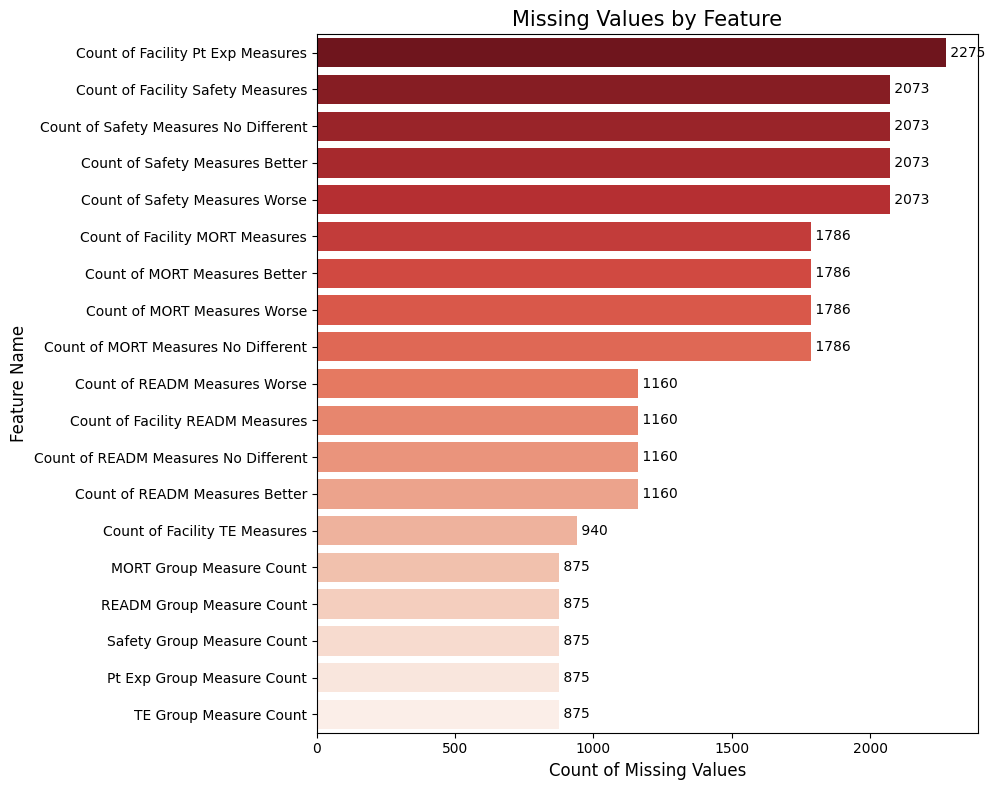

In [ ]:
#visualize missing
conf_missing_df = data_quality_conf.sort_values('Missing Values', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=conf_missing_df,
    x='Missing Values',
    y='Feature',
    palette='Reds_r'
)

plt.title('Missing Values by Feature', fontsize=15)
plt.xlabel('Count of Missing Values', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

for index, value in enumerate(conf_missing_df['Missing Values']):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

## Categorical Features

In [ ]:
#identify any categorical features
catf = df.select_dtypes(include=['object']).columns.tolist()
catf

['Facility ID',
 'Facility Name',
 'Address',
 'City/Town',
 'State',
 'ZIP Code',
 'County/Parish',
 'Telephone Number',
 'Hospital Type',
 'Hospital Ownership',
 'Emergency Services',
 'Meets criteria for birthing friendly designation',
 'Hospital overall rating',
 'Hospital overall rating footnote',
 'Safety Group Footnote']

In [ ]:
#identify any columns to filter out from the "categorical features"
catf_exclude = ['Hospital overall rating footnote', 'Safety Group Footnote', 'Telephone Number', 'Address']
filter_catf = [x for x in catf if x not in catf_exclude]
filter_catf

['Facility ID',
 'Facility Name',
 'City/Town',
 'State',
 'ZIP Code',
 'County/Parish',
 'Hospital Type',
 'Hospital Ownership',
 'Emergency Services',
 'Meets criteria for birthing friendly designation',
 'Hospital overall rating']

In [ ]:
#create lists to store modes & frequencies
modes = []
mode_freqs = []
second_modes = []
second_mode_freqs = []
mode_percentages = []
second_mode_percentages = []

In [ ]:
# Calculate mode and frequency for each categorical feature
for feature in filter_catf:
    count = df[feature].count()
    mode = df[feature].mode().iloc[0]
    mode_freq = df[feature].value_counts().iloc[0]
    modes.append(mode)
    mode_freqs.append(mode_freq)
    mode_percentages.append((mode_freq / count) * 100 if count > 0 else 0)

    # Calculate second mode and its frequency
    if len(df[feature].value_counts()) > 1:
        second_mode = df[feature].value_counts().index[1]
        second_mode_freq = df[feature].value_counts().iloc[1]
    else:
        second_mode = None
        second_mode_freq = 0

    second_modes.append(second_mode)
    second_mode_freqs.append(second_mode_freq)
    second_mode_percentages.append((second_mode_freq / count) * 100 if count > 0 else 0)

In [ ]:
# Get unique values and counts
cat_count = df[filter_catf].value_counts(ascending = False)
cat_count

,,,,,,,,,,,count
Facility ID,Facility Name,City/Town,State,ZIP Code,County/Parish,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for birthing friendly designation,Hospital overall rating,
670309,TEXAS HEALTH HOSPITAL MANSFIELD,MANSFIELD,TX,76063,TARRANT,Acute Care Hospitals,Proprietary,Yes,Y,Not Available,1
010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,4,1
010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,1
010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,LAUDERDALE,Acute Care Hospitals,Proprietary,Yes,Y,2,1
010012,DEKALB REGIONAL MEDICAL CENTER,FORT PAYNE,AL,35968,DE KALB,Acute Care Hospitals,Proprietary,Yes,Y,3,1
...,...,...,...,...,...,...,...,...,...,...,...
010049,MEDICAL CENTER ENTERPRISE,ENTERPRISE,AL,36330,COFFEE,Acute Care Hospitals,Proprietary,Yes,Y,3,1
010040,GADSDEN REGIONAL MEDICAL CENTER,GADSDEN,AL,35903,ETOWAH,Acute Care Hospitals,Proprietary,Yes,Y,1,1
010039,HUNTSVILLE HOSPITAL,HUNTSVILLE,AL,35801,MADISON,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,2,1


In [ ]:
#build quality report table
data_quality_catf = pd.DataFrame({
    'Feature': filter_catf,
    'Count': df[filter_catf].count().values,
    'Missing Values': df[filter_catf].isnull().sum().values,
    'Cardinality': df[filter_catf].nunique().values,
    'Mode':modes,
    'Mode Frequency':mode_freqs,
    'Mode %': mode_percentages,
    '2nd Mode':second_modes,
    '2nd Mode Frequency': second_mode_freqs,
    '2nd Mode %': second_mode_percentages,
})
data_quality_catf

,Feature,Count,Missing Values,Cardinality,Mode,Mode Frequency,Mode %,2nd Mode,2nd Mode Frequency,2nd Mode %
0,Facility ID,5426,0,5426,010001,1,0.018430,010001,1,0.018430
1,Facility Name,5426,0,5295,MEMORIAL HOSPITAL,12,0.221157,COMMUNITY MEMORIAL HOSPITAL,5,0.092149
2,City/Town,5426,0,3049,CHICAGO,34,0.626613,HOUSTON,31,0.571323
3,State,5426,0,56,TX,465,8.569849,CA,378,6.966458
4,ZIP Code,5426,0,4725,77030,7,0.129008,78229,6,0.110579
5,County/Parish,5426,0,1555,LOS ANGELES,88,1.621821,COOK,59,1.087357
6,Hospital Type,5426,0,8,Acute Care Hospitals,3116,57.427202,Critical Access Hospitals,1376,25.359381
7,Hospital Ownership,5426,0,12,Voluntary non-profit - Private,2304,42.462219,Proprietary,1069,19.701438
8,Emergency Services,5426,0,2,Yes,4499,82.915592,No,927,17.084408
9,Meets criteria for birthing friendly designation,2265,3161,1,Y,2265,100.000000,None,0,0.000000


# Univariate Analysis

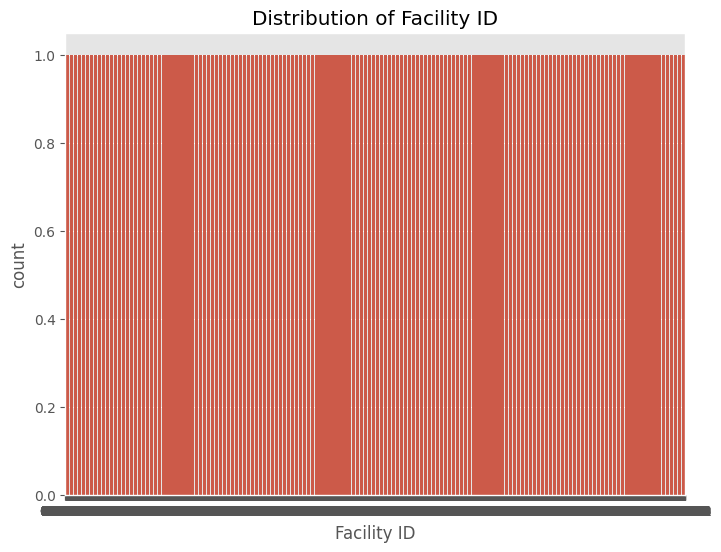

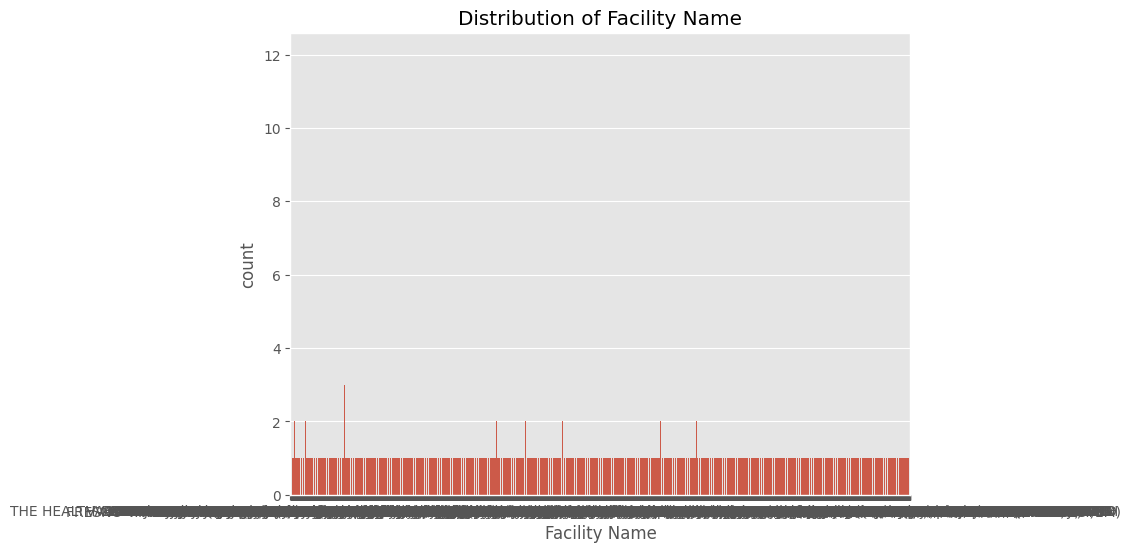

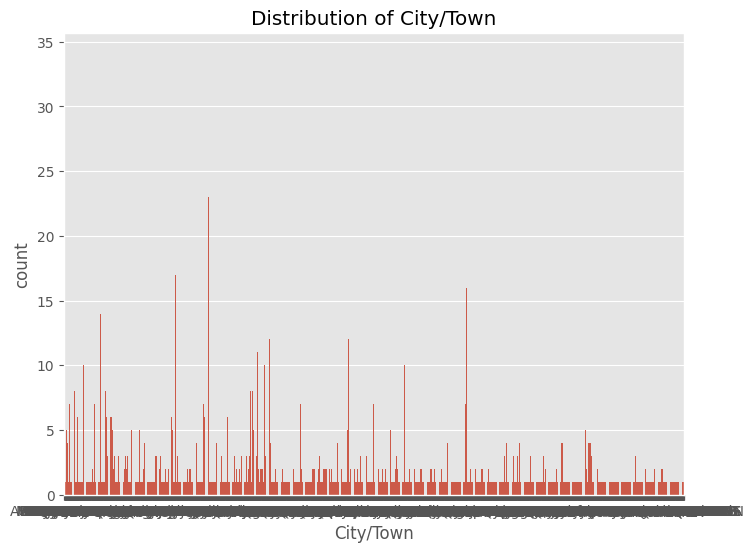

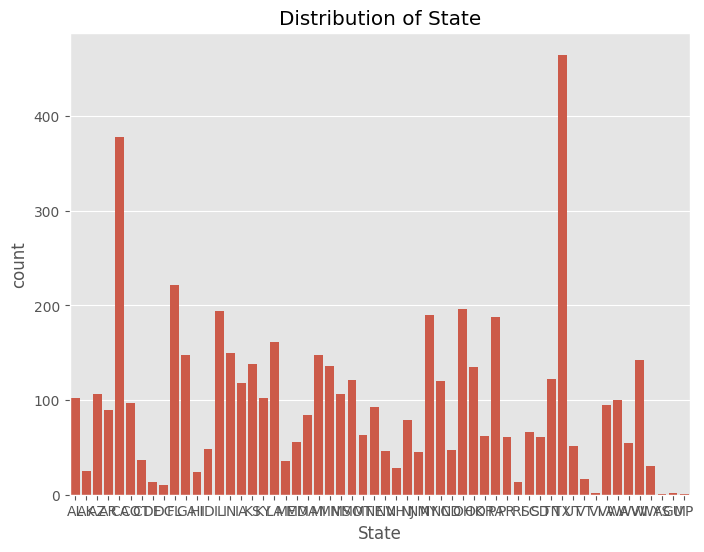

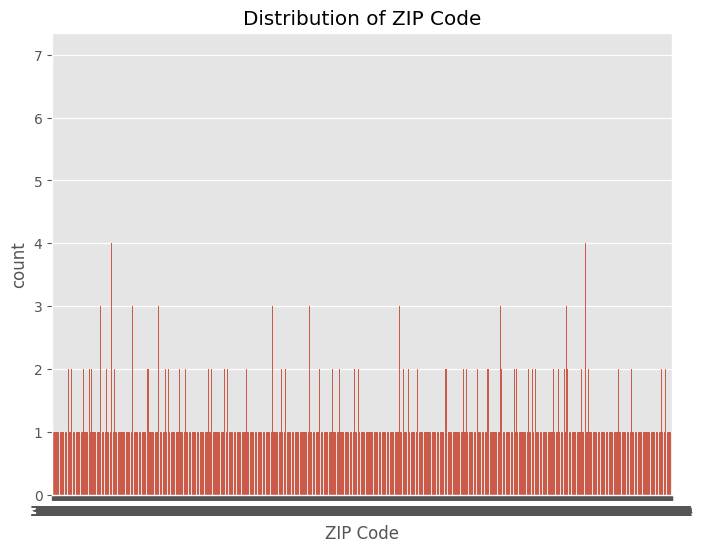

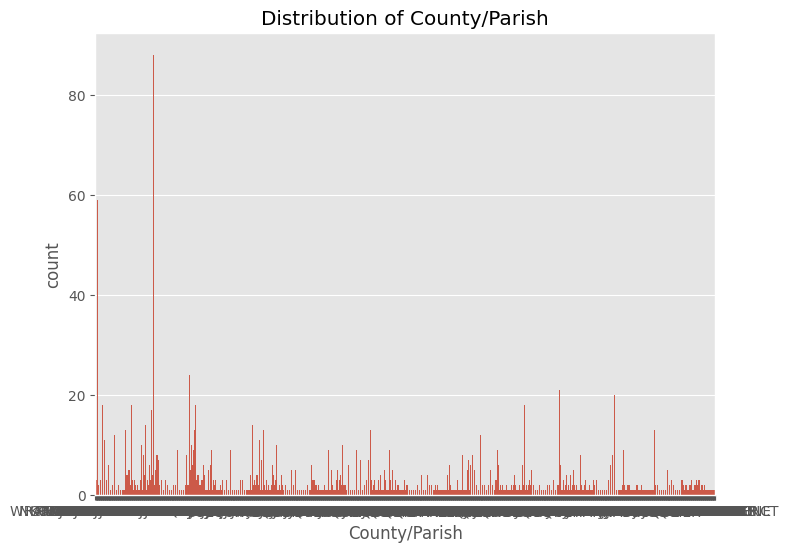

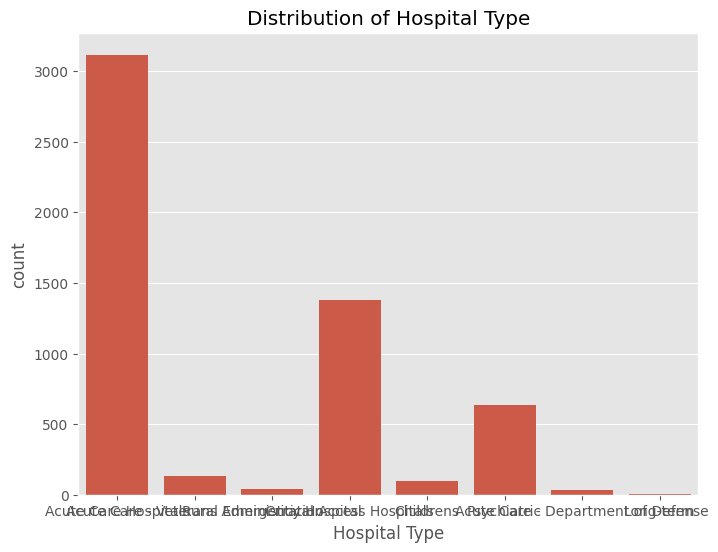

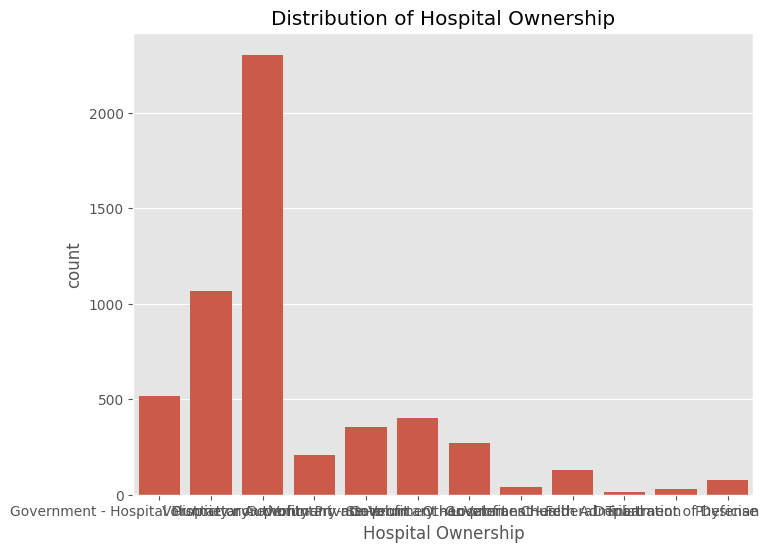

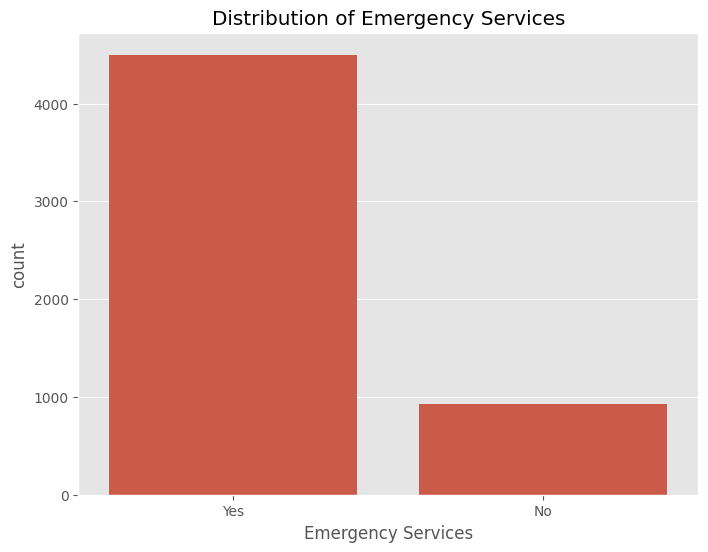

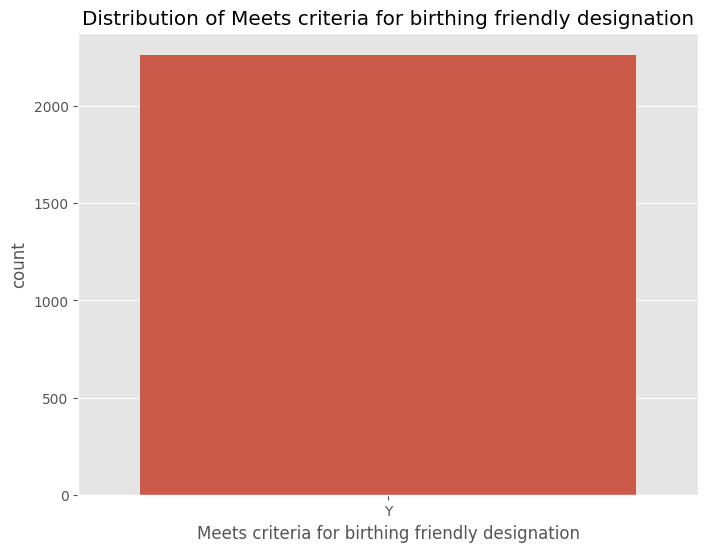

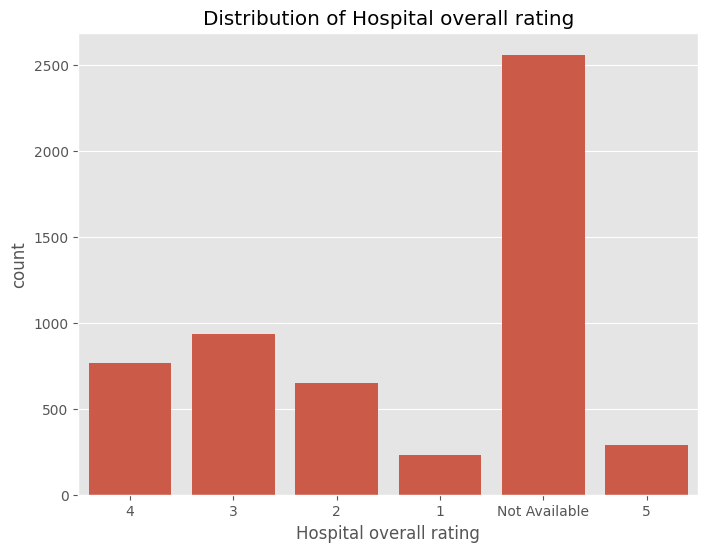

In [ ]:
#plot the categorical variables
plt.style.use('ggplot')

for column in filter_catf:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=column, data=df)
    plt.title(f'Distribution of {column}')
    plt.show()

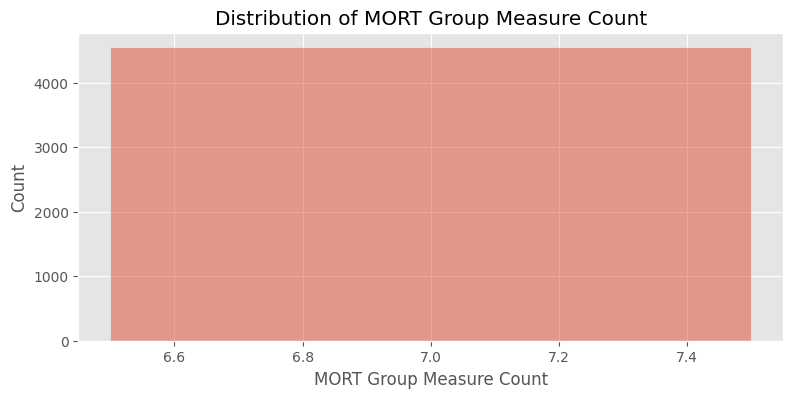

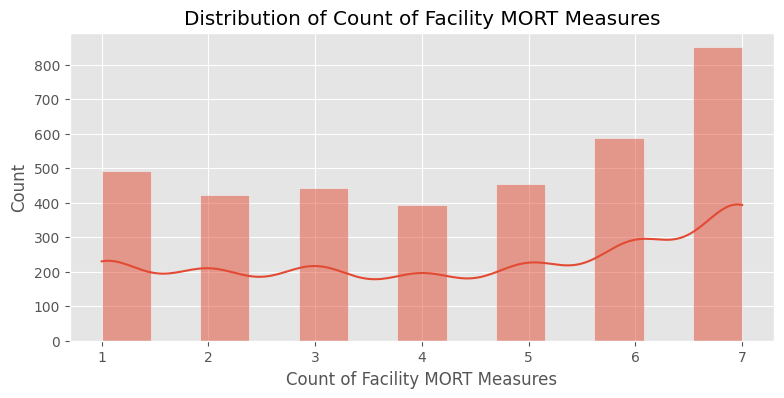

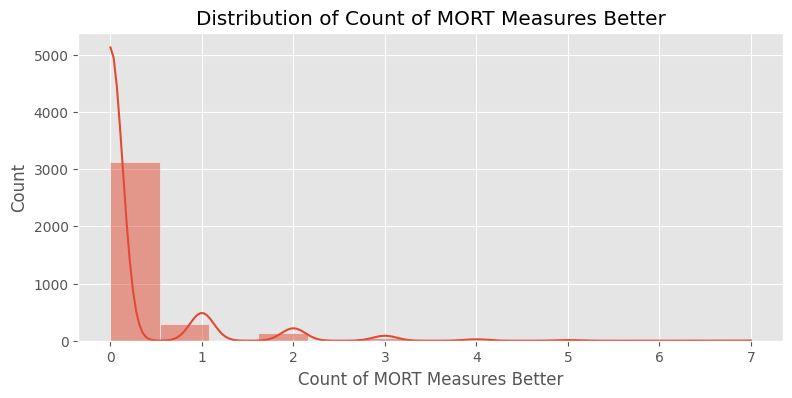

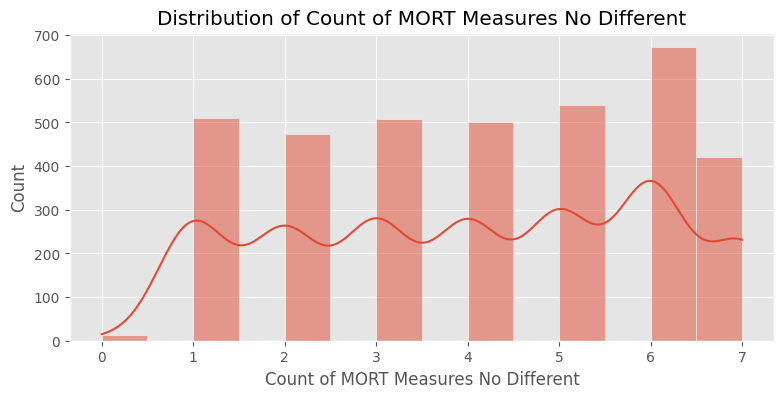

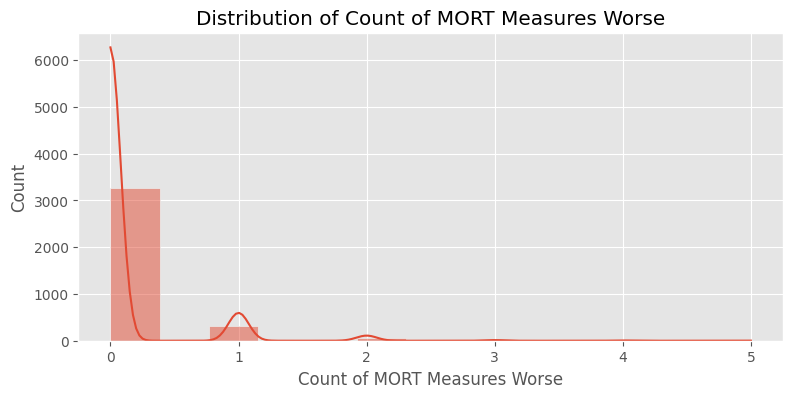

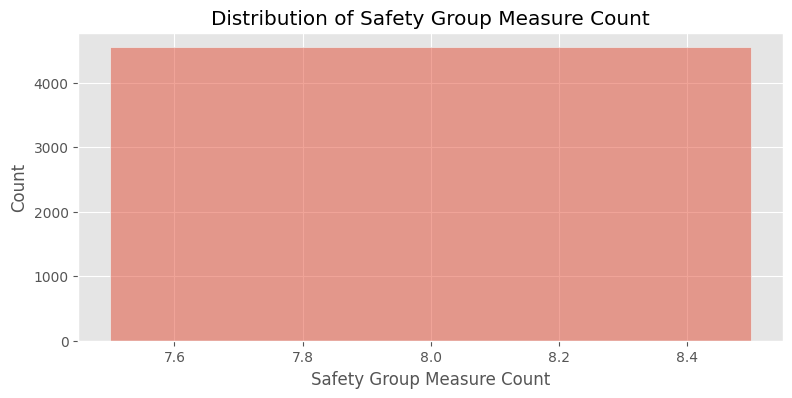

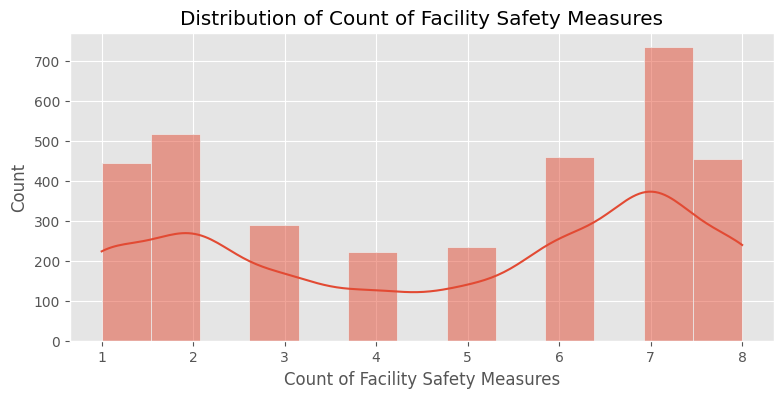

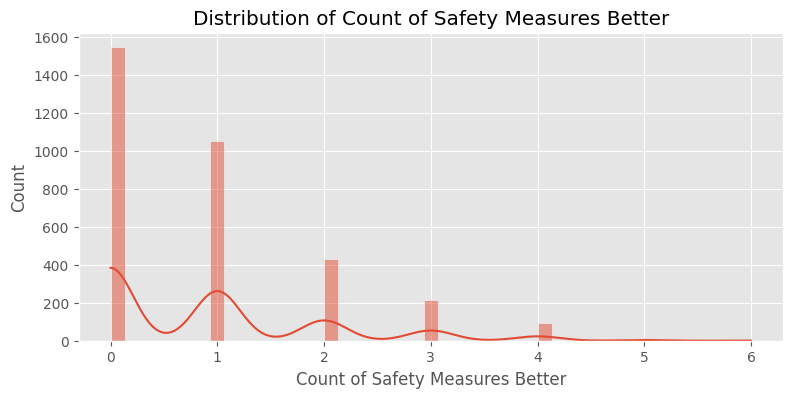

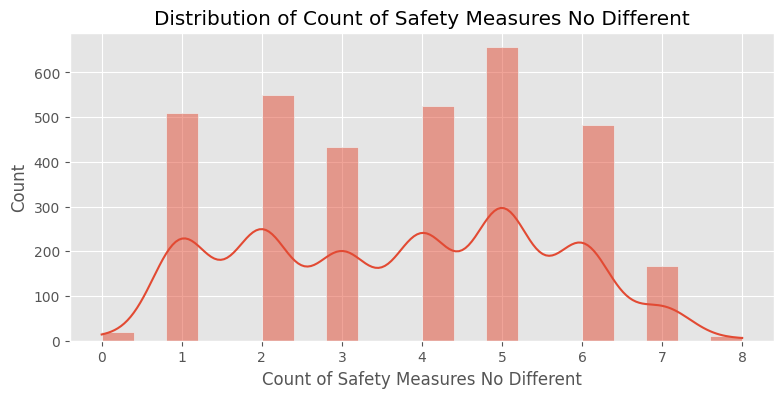

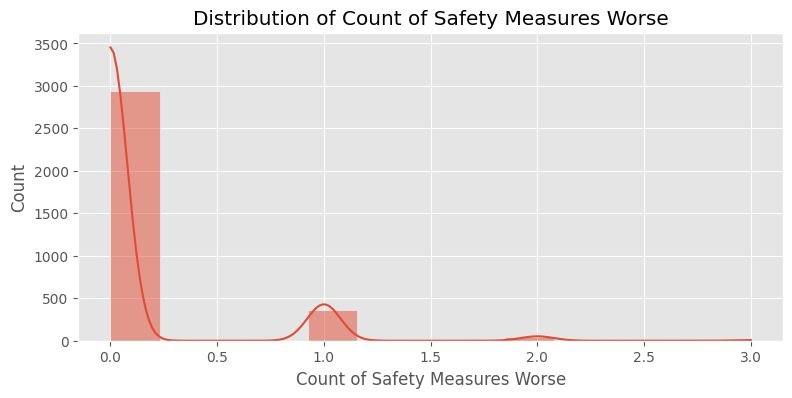

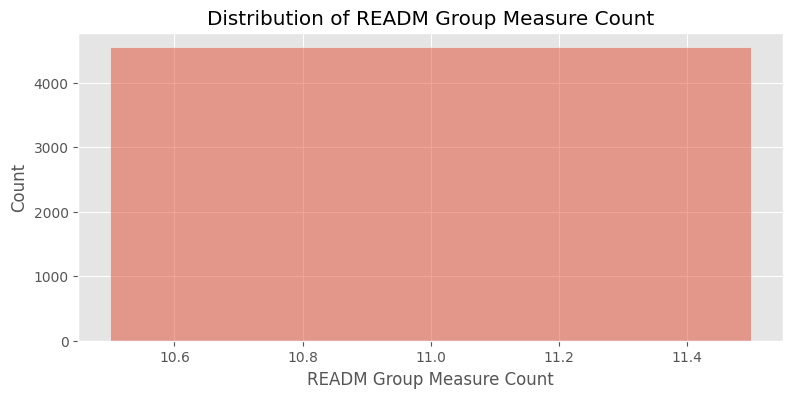

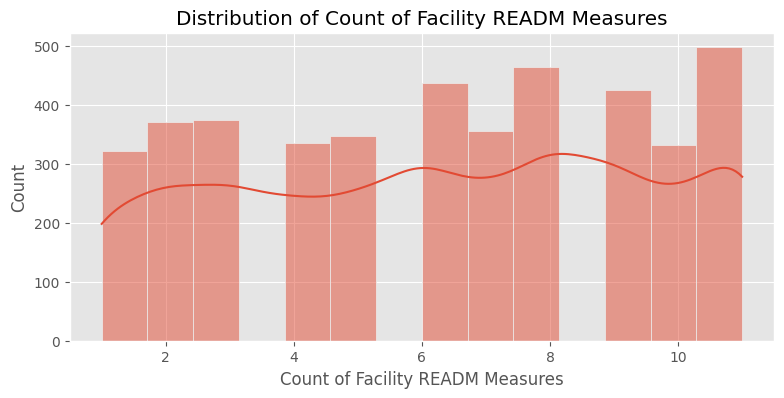

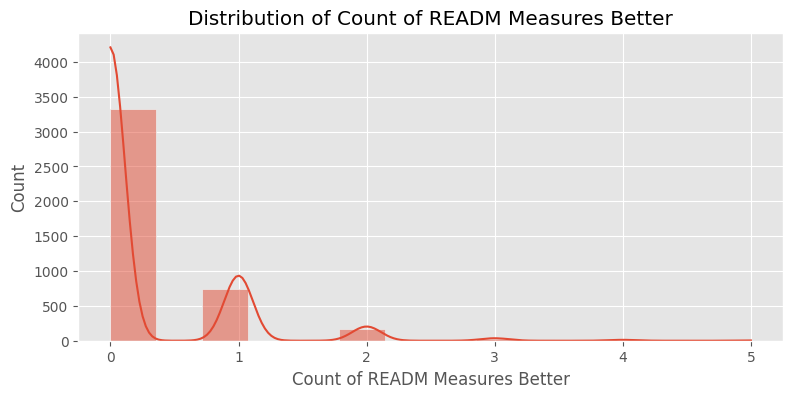

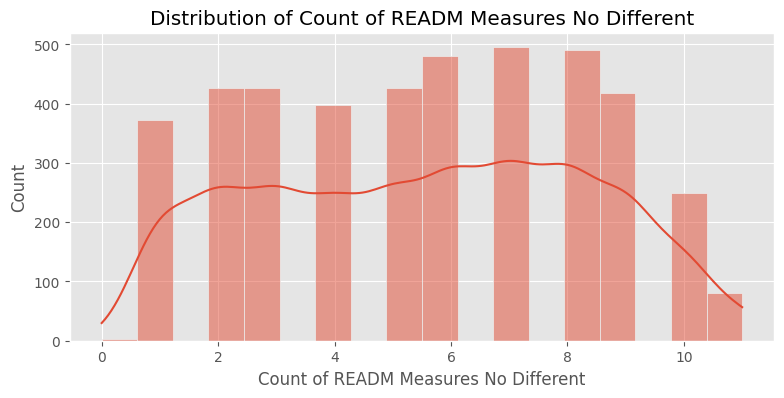

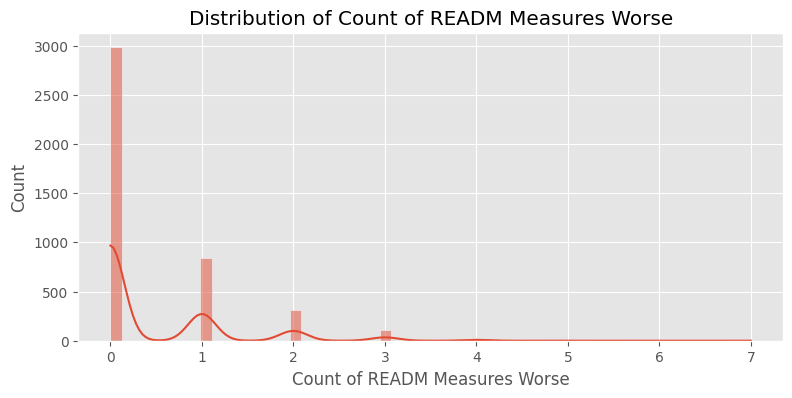

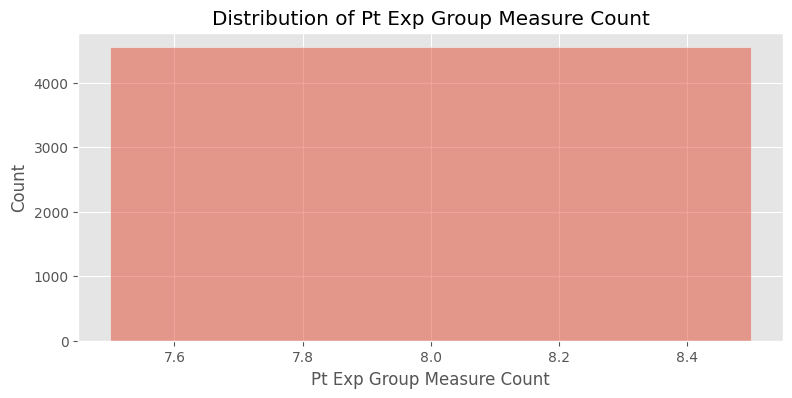

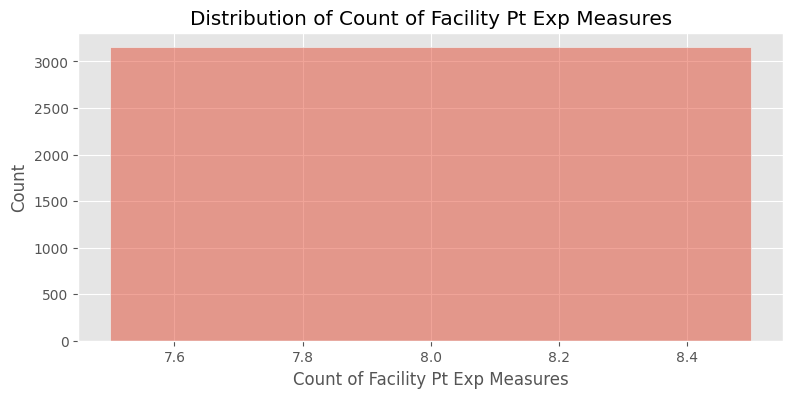

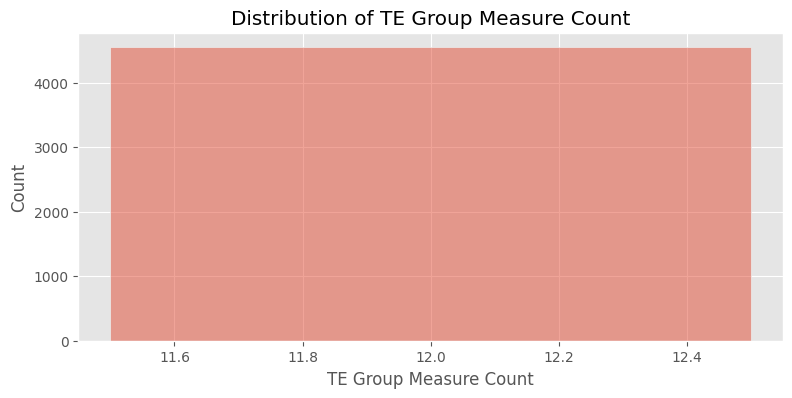

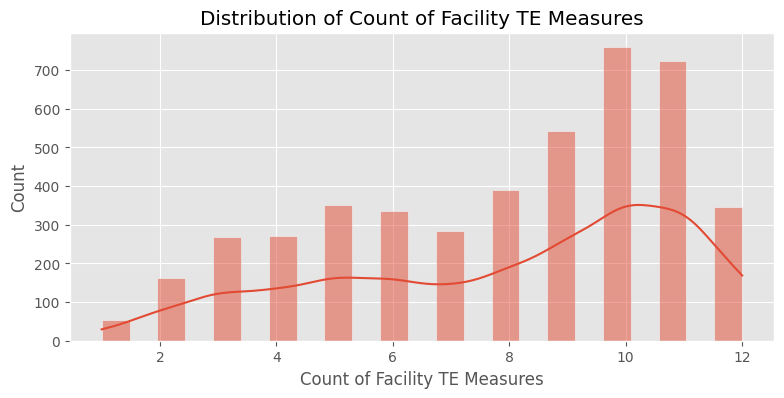

In [ ]:
#plot histograms for numerical variables
plt.style.use('ggplot')
for column in filter_conf:
    plt.figure(figsize=(20, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde = True)
    plt.title(f'Distribution of {column}')
    plt.show()

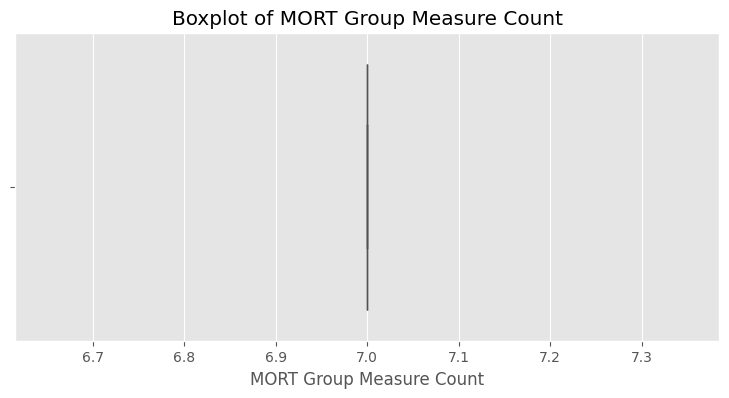

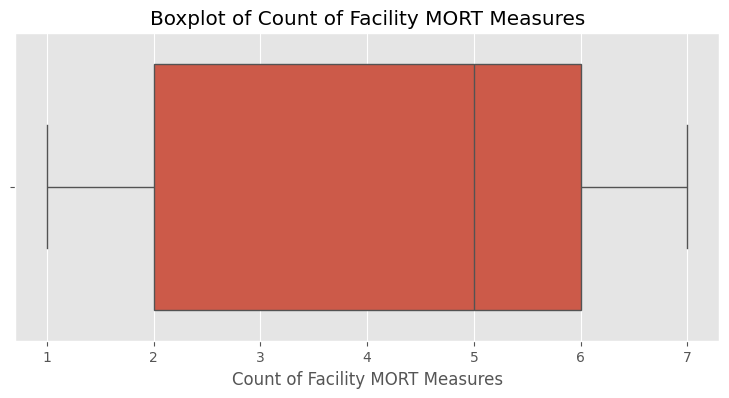

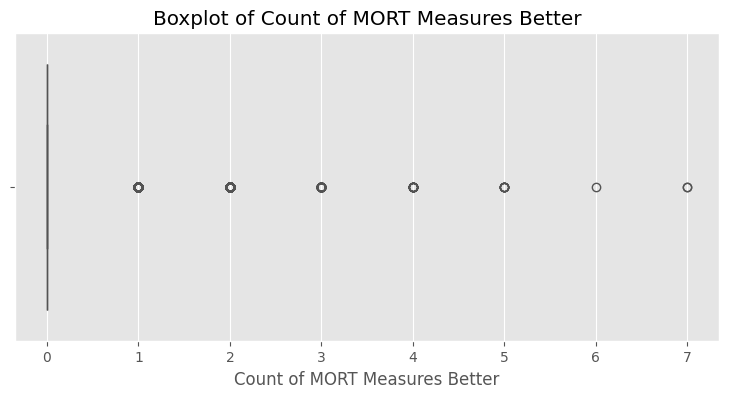

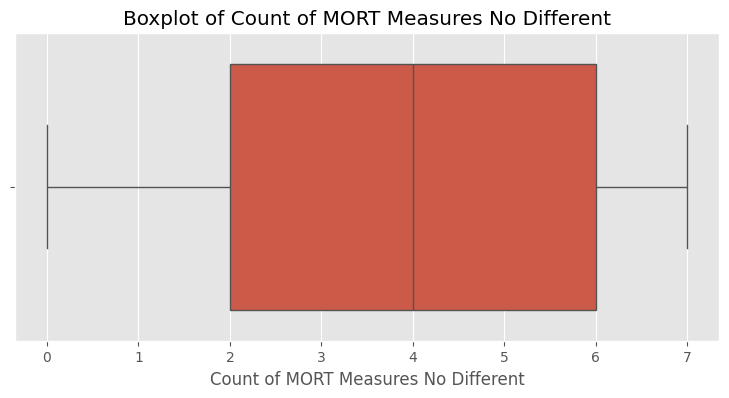

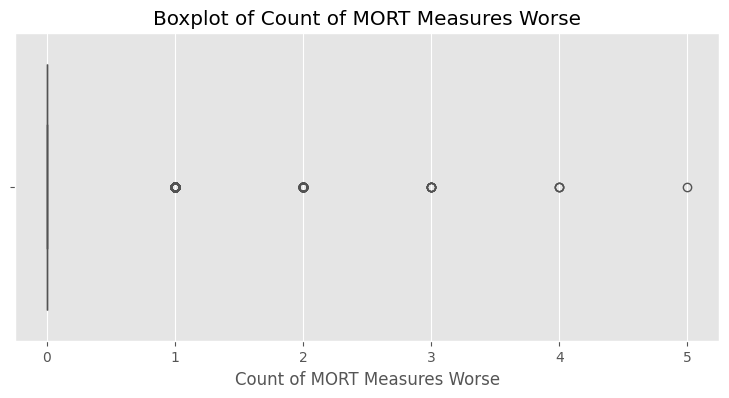

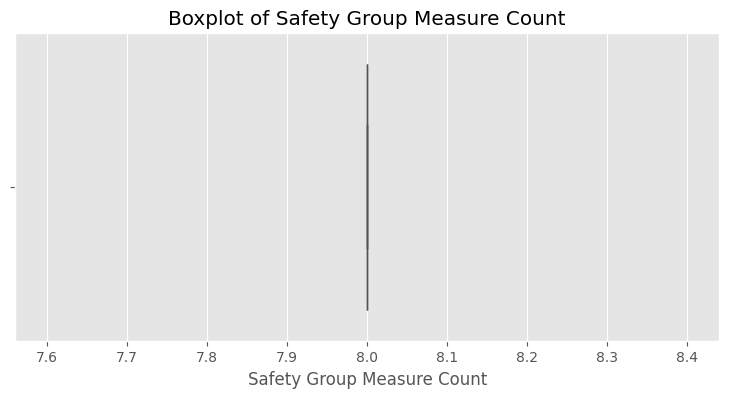

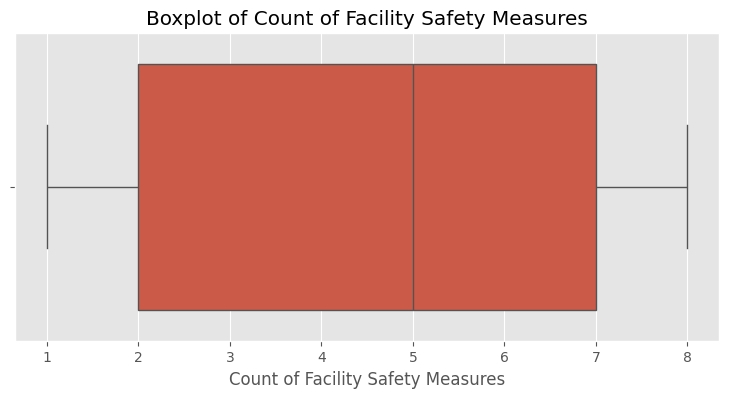

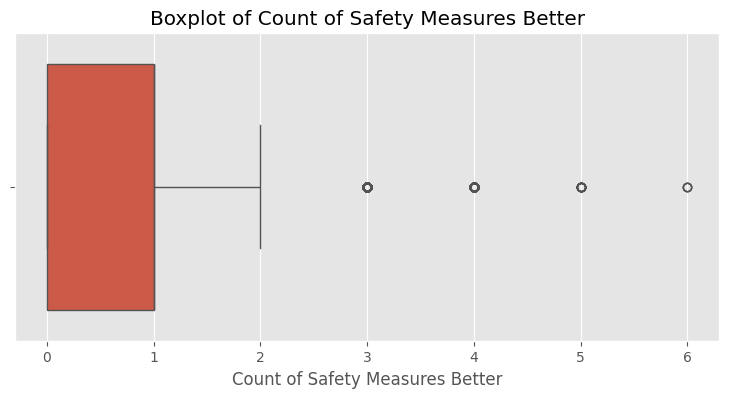

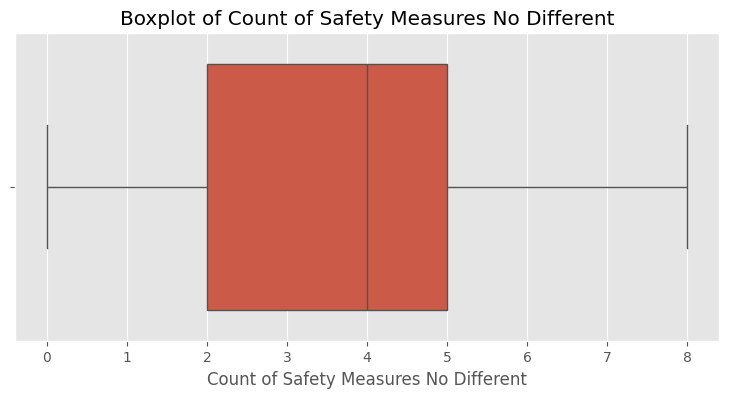

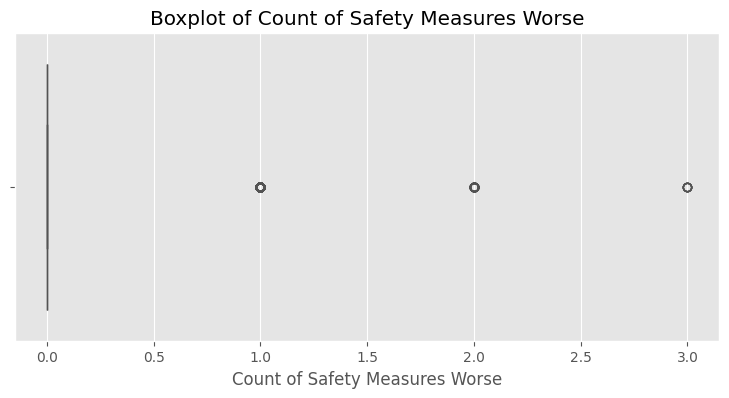

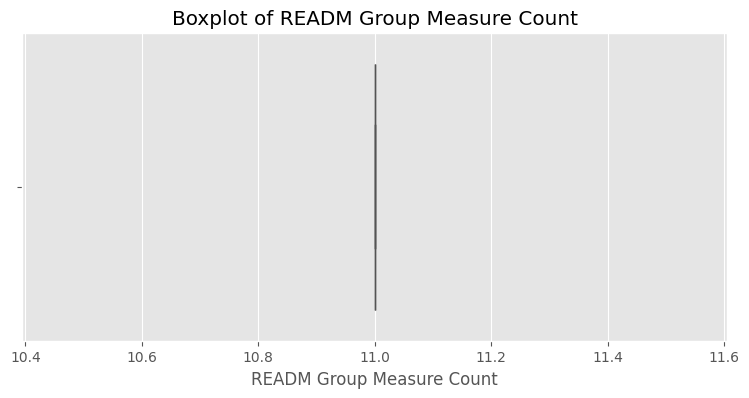

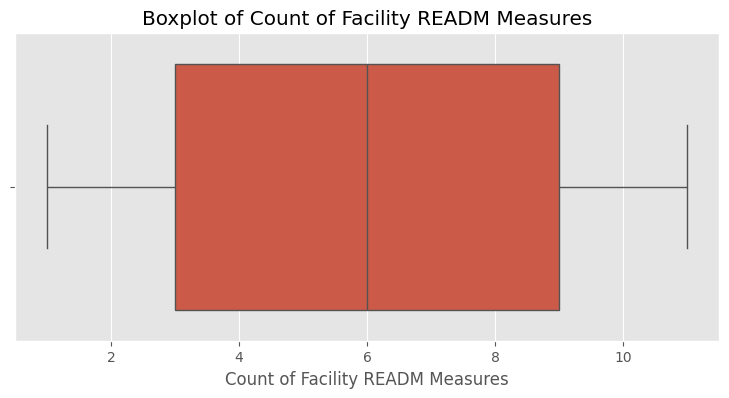

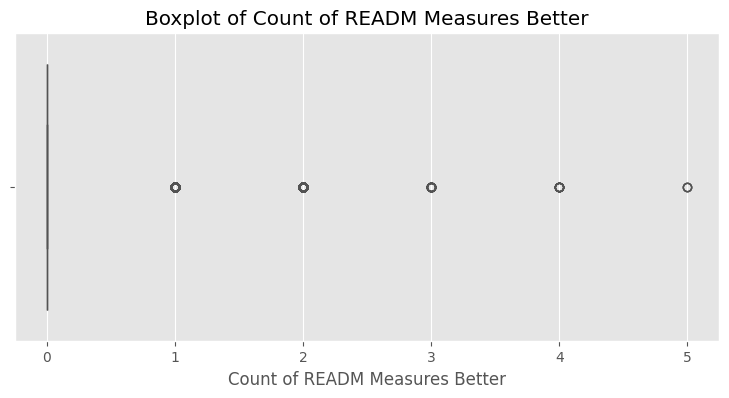

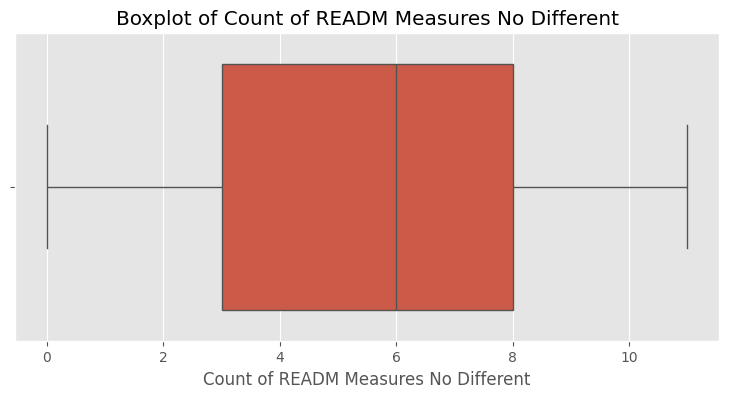

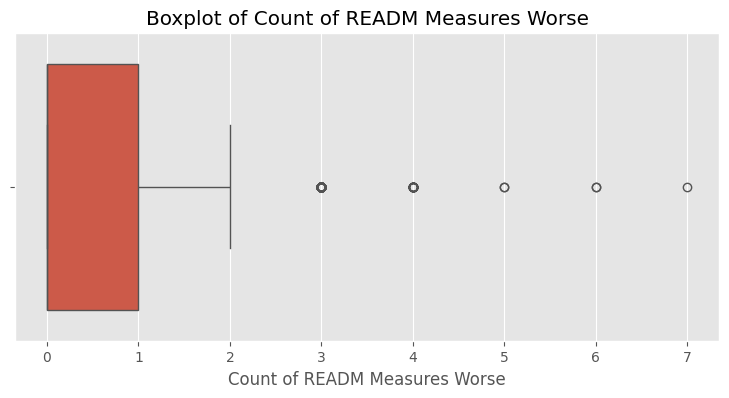

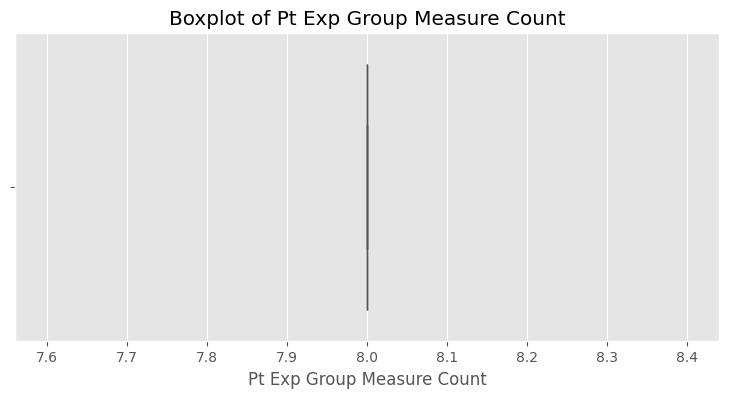

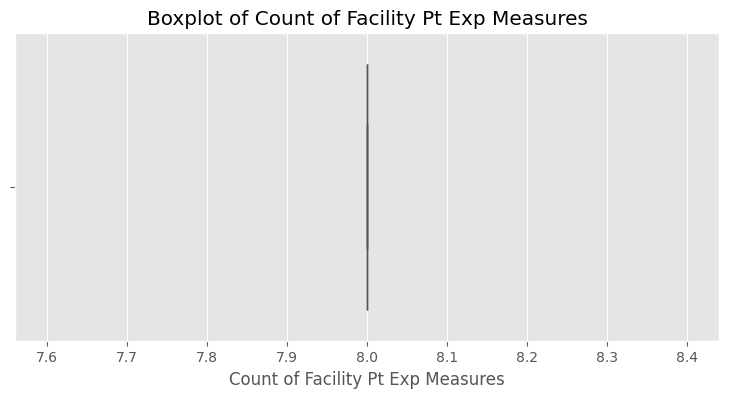

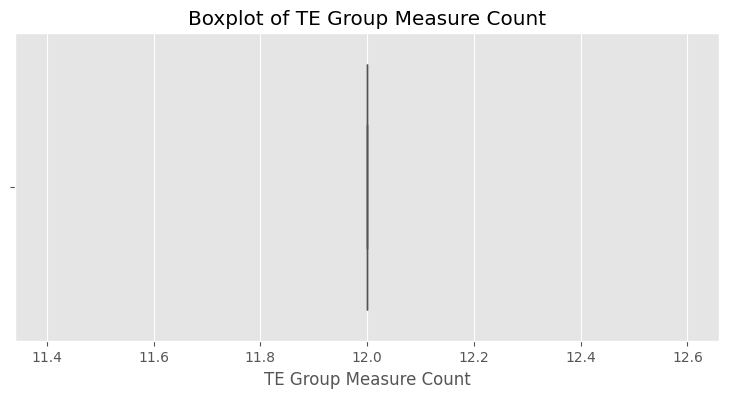

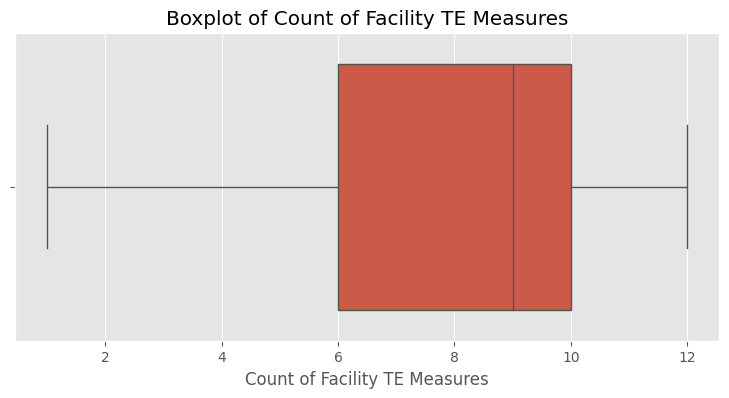

In [ ]:
#plot boxplots of all continuous features
plt.style.use('ggplot')
for column in filter_conf:
    plt.figure(figsize=(20, 4))
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

# Multivariate Analysis

## Correlations

In [ ]:
#correlations
corr_matrix = df[filter_conf].corr()
corr_matrix

,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,TE Group Measure Count,Count of Facility TE Measures
MORT Group Measure Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count of Facility MORT Measures,NaN,1.000000,0.287728,0.933564,0.213088,NaN,0.838166,0.612555,0.690996,0.229695,NaN,0.877229,0.194413,0.782791,0.421312,NaN,NaN,NaN,0.682942
Count of MORT Measures Better,NaN,0.287728,1.000000,-0.015615,-0.080314,NaN,0.252893,0.284912,0.146925,0.072295,NaN,0.254112,0.183252,0.153599,0.242171,NaN,NaN,NaN,0.116618
Count of MORT Measures No Different,NaN,0.933564,-0.015615,1.000000,0.048742,NaN,0.741689,0.498017,0.641111,0.190375,NaN,0.812075,0.138149,0.750235,0.346090,NaN,NaN,NaN,0.659819
Count of MORT Measures Worse,NaN,0.213088,-0.080314,0.048742,1.000000,NaN,0.160698,0.130709,0.113884,0.091411,NaN,0.216841,0.040356,0.190827,0.117751,NaN,NaN,NaN,0.173874
Safety Group Measure Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count of Facility Safety Measures,NaN,0.838166,0.252893,0.741689,0.160698,NaN,1.000000,0.678043,0.882658,0.242150,NaN,0.753521,0.144929,0.648380,0.397263,NaN,NaN,NaN,0.595549
Count of Safety Measures Better,NaN,0.612555,0.284912,0.498017,0.130709,NaN,0.678043,1.000000,0.288654,0.133518,NaN,0.533750,0.147425,0.425642,0.342854,NaN,NaN,NaN,0.385087
Count of Safety Measures No Different,NaN,0.690996,0.146925,0.641111,0.113884,NaN,0.882658,0.288654,1.000000,0.029765,NaN,0.647775,0.104519,0.579188,0.295007,NaN,NaN,NaN,0.543372
Count of Safety Measures Worse,NaN,0.229695,0.072295,0.190375,0.091411,NaN,0.242150,0.133518,0.029765,1.000000,NaN,0.194056,0.007915,0.157944,0.149735,NaN,NaN,NaN,0.113858


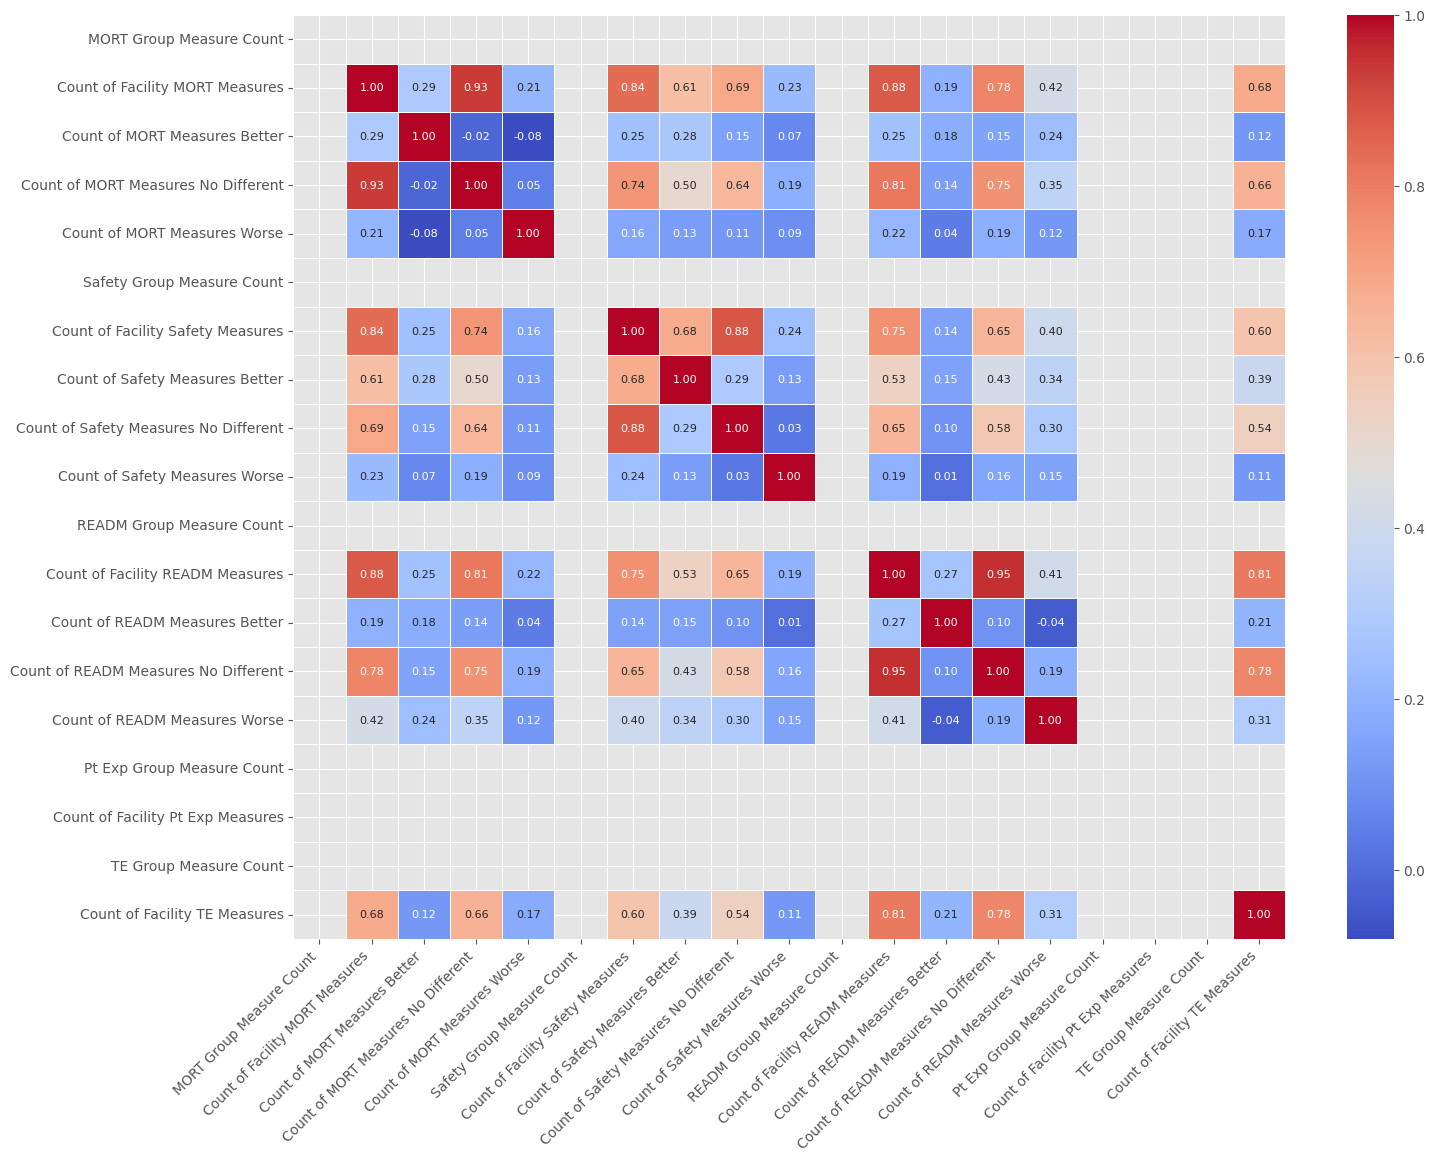

In [ ]:
# Create a heatmap
plt.figure(figsize=(16, 12))
heatmap = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})

# Rotate the x and y labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Show the heatmap
plt.show()